Импортируем библиотеки

In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

## Подготовка данных

Загружаем датасет

In [ ]:
uploaded = files.upload()

In [ ]:
data = pd.read_csv('emotions.csv')

In [ ]:
data

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.620,30.3,-356.0,15.60,26.3,1.070,0.411,-15.700,2.060,3.15,...,23.50,20.300,20.300,23.50,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.800,33.1,32.0,25.80,22.8,6.550,1.680,2.880,3.830,-4.82,...,-23.30,-21.800,-21.800,-23.30,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.900,29.4,-416.0,16.70,23.7,79.900,3.360,90.200,89.900,2.03,...,462.00,-233.000,-233.000,462.00,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.900,31.6,-143.0,19.80,24.3,-0.584,-0.284,8.820,2.300,-1.97,...,299.00,-243.000,-243.000,299.00,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.300,31.3,45.2,27.30,24.5,34.800,-5.790,3.060,41.400,5.52,...,12.00,38.100,38.100,12.00,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2127,32.400,32.2,32.2,30.80,23.4,1.640,-2.030,0.647,-0.121,-1.10,...,-21.70,0.218,0.218,-21.70,95.2,-19.90,47.20,47.20,-19.90,NEUTRAL
2128,16.300,31.3,-284.0,14.30,23.9,4.200,1.090,4.460,4.720,6.63,...,594.00,-324.000,-324.000,594.00,-35.5,142.00,-59.80,-59.80,142.00,POSITIVE
2129,-0.547,28.3,-259.0,15.80,26.7,9.080,6.900,12.700,2.030,4.64,...,370.00,-160.000,-160.000,370.00,408.0,-169.00,-10.50,-10.50,-169.00,NEGATIVE
2130,16.800,19.9,-288.0,8.34,26.0,2.460,1.580,-16.000,1.690,4.74,...,124.00,-27.600,-27.600,124.00,-656.0,552.00,-271.00,-271.00,552.00,NEGATIVE


Выделение признаков и меток

In [ ]:
fft_columns = [col for col in data.columns if col.startswith("fft")]
data_fft = data[fft_columns]

labels = data['label']

In [ ]:
data_fft.head()

,fft_0_a,fft_1_a,fft_2_a,fft_3_a,fft_4_a,fft_5_a,fft_6_a,fft_7_a,fft_8_a,fft_9_a,...,fft_740_b,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b
0,-520.0,398.00,-201.0,-201.0,398.00,-52.2,121.00,-64.0,-64.0,121.00,...,74.3,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00
1,66.2,-4.30,43.6,43.6,-4.30,66.0,-29.00,73.3,73.3,-29.00,...,130.0,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57
2,-90.8,204.00,-77.1,-77.1,204.00,-488.0,415.00,-187.0,-187.0,415.00,...,-534.0,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00
3,119.0,6.25,10.9,10.9,6.25,-333.0,283.00,-144.0,-144.0,283.00,...,-183.0,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40
4,59.0,-2.37,10.8,10.8,-2.37,118.0,-1.81,26.7,26.7,-1.81,...,114.0,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60


In [ ]:
labels.head()

,label
0,NEGATIVE
1,NEUTRAL
2,POSITIVE
3,POSITIVE
4,NEUTRAL


Кодирование меток классов

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

Формирование массивов признаков и меток

In [ ]:
X = data_fft.values
y = np.array(y)

Нормализация признаков

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Разделение данных на обучающую и тестовую выборки

In [ ]:
X_flat = X

# Разделяем данные: 80% — обучение, 20% — тест
X_tr_flat, X_te_flat, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
def to_gru(x_flat):
    # Делим признаки на две половины
    mid = x_flat.shape[1] // 2
    a = x_flat[:, :mid]    # первая половина
    b = x_flat[:, mid:]    # вторая половина
    return np.stack((a, b), axis=-1)

In [ ]:
X_train = to_gru(X_tr_flat)
X_test  = to_gru(X_te_flat)

## Настройка методов отбора признаков

Теперь мы проведём **сравнительный анализ различных методов отбора признаков**.  
Для каждого метода из словаря selectors мы переберём заданные параметры и оценим качество модели с выбранными признаками, используя кросс-валидацию.

In [ ]:
selectors = {
    'SelectKBest': {
        'class': SelectKBest,
        'params': {'score_func': f_classif},
        'grid': {'k': [50, 100, 500, X.shape[1]]}  # число лучших признаков
    },
    'SelectFromModel_RF': {
        'class': SelectFromModel,
        'params': {
            'estimator': RandomForestClassifier(n_estimators=200, random_state=42)
        },
        'grid': {'threshold': ['median']}  # отбираем признаки выше медианы важности
    },
    'L1_LinearSVC': {
        'class': SelectFromModel,
        'params': {
            'estimator': LinearSVC(C=0.01, penalty='l1', dual=False, max_iter=5000)
        },
        'grid': {'threshold': [None]}  # оставляем признаки с ненулевыми весами
    }
}

In [ ]:
best_acc = 0.0
best_name = None
best_selector = None

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
# Проходим по каждому способу отбора признаков
for name, spec in selectors.items():
    Cls         = spec['class']
    base_kwargs = spec['params']
    for param, values in spec['grid'].items():
        for v in values:
            # Создаём селектор с конкретным параметром
            sel_kwargs = base_kwargs.copy()
            sel_kwargs[param] = v
            sel = Cls(**sel_kwargs)

            # Отбираем признаки на обучающих данных
            X_tr_sel = sel.fit_transform(X_tr_flat, y_train)
            X_va_sel = sel.transform(X_te_flat)

            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            # Оцениваем модель по кросс-валидации
            scores = []
            for train_idx, val_idx in cv.split(X_tr_sel, y_train):
                rf.fit(X_tr_sel[train_idx], y_train[train_idx])
                scores.append(rf.score(X_tr_sel[val_idx], y_train[val_idx]))
            mean_cv = np.mean(scores)

            # Считаем число признаков
            n_feats = X_tr_sel.shape[1]

            print(f"{name}: {param}={v} → CV acc={mean_cv:.2f}, n_feats={n_feats}")

            # Обновим лучший результат, если текущий лучше
            if mean_cv > best_acc:
                best_acc      = mean_cv
                best_name     = name
                best_selector = sel

SelectKBest: k=50 → CV acc=0.8106, n_feats=50
SelectKBest: k=100 → CV acc=0.8610, n_feats=100
SelectKBest: k=500 → CV acc=0.8856, n_feats=500
SelectKBest: k=1500 → CV acc=0.9255, n_feats=1500
SelectFromModel_RF: threshold=median → CV acc=0.9267, n_feats=750
L1_LinearSVC: threshold=None → CV acc=0.9284, n_feats=188


In [ ]:
print(f"\nЛучший метод: {best_name}, CV accuracy={best_acc:.2f}")


Лучший метод: L1_LinearSVC, CV accuracy=0.9284


После перебора всех методов и параметров с использованием кросс-валидации был выбран наиболее эффективный способ отбора признаков: L1_LinearSVC.
Это означает, что модель LinearSVC с L1-регуляризацией смогла эффективно обнулить менее важные признаки и оставить только значимые.

Теперь мы можем применить best_selector для сокращения признаков в обучающей и тестовой выборках перед подачей в модель GRU.

In [ ]:
best_selector.fit(X_tr_flat, y_train)
X_sel_flat = best_selector.transform(X_tr_flat)
X_sel_count = X_sel_flat.shape[1]

print(f"   Оставлено признаков: {X_sel_count}")

   Оставлено признаков: 196


Осталось 196 признаков, которые были признаны наиболее значимыми на основе весов модели LinearSVC с L1-регуляризацией.

In [ ]:
X_tr_sel_flat = best_selector.transform(X_tr_flat)
X_te_sel_flat = best_selector.transform(X_te_flat)
X_train_sel = to_gru(X_tr_sel_flat)
X_test_sel  = to_gru(X_te_sel_flat)

# Настройка и обучение GRU

Построение и конфигурация модели GRU

In [ ]:
param_grid = {
    'units':   [32, 64],     # количество нейронов в GRU
    'dropout': [0.2, 0.5],   # уровень Dropout-регуляризации
    'lr':      [1e-3, 1e-4], # скорость обучения (learning rate)
}
fixed = {
    'features':    2,     # количество каналов на каждый шаг
    'dense_units': 32,    # размер промежуточного Dense-слоя
    'batch_size':  32,
    'epochs':      50,
    'patience':     5     # EarlyStopping — количество эпох без улучшения
}

Для удобства повторного использования и автоматического перебора параметров  
создадим функцию `make_model`, которая будет возвращать готовую модель GRU  
с заданными значениями `units`, `dropout` и `learning rate`.

GRU(units): рекуррентный слой для обработки последовательных признаков.

Dropout(dropout): регуляризация для борьбы с переобучением.

Dense(fixed['dense_units']): промежуточный слой с активацией ReLU.

Dense(len(label_encoder.classes_)): выходной слой с softmax для классификации на 3 эмоции.

Adam(learning_rate=lr): оптимизатор с переданной скоростью обучения.

In [ ]:
def make_model(units, dropout, lr):
    m = Sequential([
        GRU(units, input_shape=(fixed['timesteps'], fixed['features'])),
        Dropout(dropout),
        Dense(fixed['dense_units'], activation='relu'),
        Dense(len(label_encoder.classes_), activation='softmax')
    ])
    m.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

In [ ]:
# Эта функция обучает модель с заданными гиперпараметрами и возвращает максимальную точность на валидации
def eval_params(params):
    m = make_model(**params)
    es = EarlyStopping(monitor='val_accuracy',
                       patience=fixed['patience'],
                       restore_best_weights=True)
    hist = m.fit(
        X_train_sel, y_train,
        validation_data=(X_test_sel, y_test),
        epochs=fixed['epochs'],
        batch_size=fixed['batch_size'],
        callbacks=[es],
        verbose=0
    )
    return max(hist.history['val_accuracy'])

In [ ]:
best_params = {}
defaults = {k:v[0] for k,v in param_grid.items()}

Поэтапный подбор гиперпараметров GRU

In [ ]:
for key in ['units', 'dropout', 'lr']:
    best_acc = 0
    for val in param_grid[key]:
        params = defaults.copy()
        params[key] = val
        acc = eval_params(params)
        print(f"Testing {key}={val} → val_acc={acc:.2f}")
        if acc > best_acc:
            best_acc = acc
            best_params[key] = val
    defaults[key] = best_params[key]
    print(f"→ Best {key}: {best_params[key]} (val_acc={best_acc:.2f})\n")

Testing units=32    → val_acc=0.9563
Testing units=64    → val_acc=0.9540
→ Best units: 32    (val_acc=0.9563)

Testing dropout=0.2 → val_acc=0.9633
Testing dropout=0.5 → val_acc=0.9563
→ Best dropout: 0.2 (val_acc=0.9633)

Testing lr=0.001    → val_acc=0.9516
Testing lr=0.0001   → val_acc=0.7573
→ Best lr: 0.001    (val_acc=0.9516)


Меньшее количество нейронов оказалось более устойчивым и показало лучшую валидационную точность.

Меньшее значение Dropout (0.2) дало лучшее качество,
возможно, из-за отсутствия переобучения благодаря отбору признаков.

Больший learning_rate обеспечил быструю и стабильную сходимость,
в то время как слишком маленькое значение затруднило обучение.

Финальные параметры

In [ ]:
print(f"nBest params:", best_params)

nBest params: {'units': 32, 'dropout': 0.2, 'lr': 0.001}


In [ ]:
u = best_params['units']
d = best_params['dropout']
l = best_params['lr']

Финальная модель GRU с подобранными параметрами

In [ ]:
# Создание финальной модели  с подобранными параметрами
best_model = Sequential([
    GRU(u, input_shape=(196, 2), return_sequences=False),  # GRU-слой
    Dropout(d),                                             # Dropout-регуляризация для предотвращения переобучения
    Dense(32, activation='relu'),                           # Полносвязный скрытый слой
    Dense(len(label_encoder.classes_), activation='softmax')  # Выходной слой с softmax для многоклассовой классификации
])

# Компиляция модели
best_model.compile(
    optimizer=Adam(learning_rate=l),                        # Адам-оптимизатор с подобранным learning rate
    loss='sparse_categorical_crossentropy',                 # Функция потерь для целочисленных меток
    metrics=['accuracy']                                    # Метрика — точность
)

# EarlyStopping: остановка обучения при отсутствии улучшения val_accuracy
es = EarlyStopping(
    monitor='val_accuracy',     # Мониторим валидационную точность
    patience=5,                 # Кол-во эпох без улучшения до остановки
    restore_best_weights=True  # Восстановить лучшие веса после остановки
)

Обучение модели на выбранных признаках

In [ ]:
history = best_model.fit(
    X_train_sel, y_train,
    validation_data=(X_test_sel, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6034 - loss: 0.9640 - val_accuracy: 0.6612 - val_loss: 0.7909
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6977 - loss: 0.7711 - val_accuracy: 0.8041 - val_loss: 0.5141
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8591 - loss: 0.4613 - val_accuracy: 0.9189 - val_loss: 0.2802
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9334 - loss: 0.2626 - val_accuracy: 0.9423 - val_loss: 0.2428
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9514 - loss: 0.2301 - val_accuracy: 0.9423 - val_loss: 0.2238
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9458 - loss: 0.2339 - val_accuracy: 0.9446 - val_loss: 0.2194
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9537 - loss: 0.2066 - val_accuracy: 0.9470 - val_loss: 0.2081
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9611 - loss: 0.1953 - val_accuracy: 0.9446 - val_loss

Оценка качества модели на тестовой выборке

In [ ]:
# Получение вероятностей предсказаний на тестовой выборке
y_pred_proba = best_model.predict(X_test_sel)

# Преобразование вероятностей в предсказанные классы
y_pred = np.argmax(y_pred_proba, axis=1)

# Вычисление F1-метрики
f1 = f1_score(y_test, y_pred, average='weighted')

# Построение матрицы ошибок (confusion matrix)
cm = confusion_matrix(y_test, y_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [3]:
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}\n")

Test Accuracy: 0.9461
Test F1 Score: 0.9415



Модель успешно обучилась и демонстрирует хорошее качество предсказаний

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Classification Report:
              precision    recall  f1-score   support
     NEGATIVE        0.91      0.99       0.95       142
      NEUTRAL        0.99      0.98       0.99       143
     POSITIVE        0.96      0.89       0.93       142

     accuracy        0.95                 427
    macro avg        0.95      0.95       0.95       427
 weighted avg        0.95      0.95       0.95       427


NEGATIVE: Отличный recall (0.99) — модель почти всегда правильно распознаёт негативные эмоции, но precision чуть ниже (модель иногда ошибочно даёт негативный класс).

NEUTRAL: Хорошие значения — модель чётко распознаёт нейтральные состояния.

POSITIVE: Немного хуже recall (0.89), значит часть положительных примеров модель путает с другими (возможно с "NEGATIVE").

Визуализация истории обучения: потери и точность по эпохам

In [ ]:
plt.figure(figsize=(12,5))

(0.08320728987455368, 0.9044341817498206)

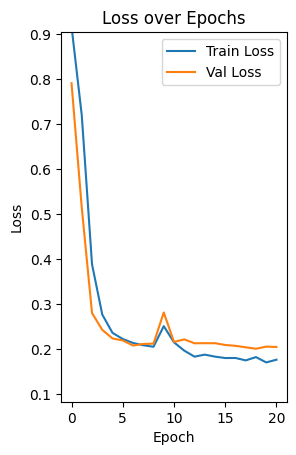

In [ ]:
# График функции потерь (Loss)
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

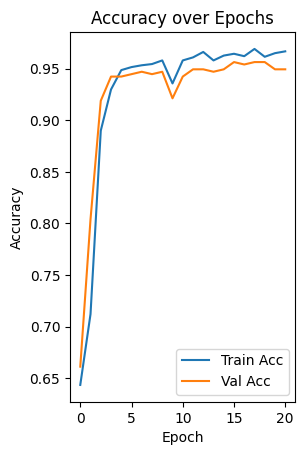

In [ ]:
# График точности (Accuracy)
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

Визуализация матрицы ошибок (Confusion Matrix)

In [ ]:
plt.tight_layout()
plt.show()

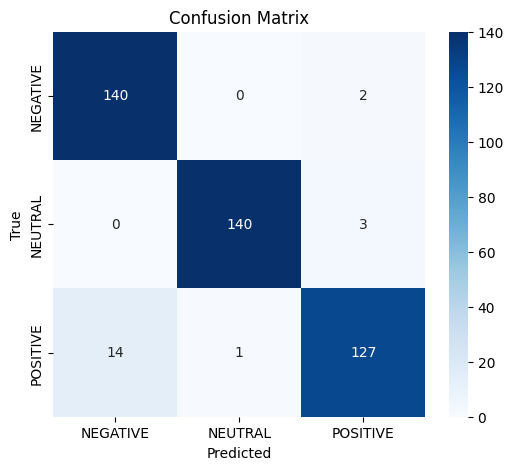

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Настройка и обучение CNN+GRU

Модель CNN + GRU: объединение свёрточных и рекуррентных слоёв

Для улучшения качества классификации мы реализуем гибридную архитектуру,  
сочетающую **свёрточную нейросеть (CNN)** и **GRU**.  
CNN поможет выявить локальные паттерны, а GRU — учесть временную зависимость.

In [ ]:
param_grid_cnn = {
    'filters':     [32, 64],
    'kernel_size': [3, 5],
    'gru_units':   [32, 64],
}

fixed_cnn = {
    'features':      2,
    'pool_size':     2,
    'dropout':     0.3,
    'dense_units': 32,
    'batch_size':  32,
    'epochs':      50,
    'patience':     5,
    'lr':        1e-3,
}

In [ ]:
# Функция создания модели
def make_cnn_gru(filters, kernel_size, gru_units):
    model = Sequential([
        # 1D-свёртка: извлечение локальных признаков
        Conv1D(filters, kernel_size, activation='relu',
               input_shape=(fixed_cnn['timesteps'], fixed_cnn['features'])),

        # Уменьшение размерности выхода свёртки
        MaxPooling1D(fixed_cnn['pool_size']),

        # Dropout для регуляризации
        Dropout(fixed_cnn['dropout']),

        # GRU-слой: захватывает временные зависимости в выходе свёртки
        GRU(gru_units),

        # Ещё один Dropout
        Dropout(fixed_cnn['dropout']),

        # Полносвязный слой + выходной softmax
        Dense(fixed_cnn['dense_units'], activation='relu'),
        Dense(len(label_encoder.classes_), activation='softmax')
    ])

    # Компиляция модели
    model.compile(
        optimizer=Adam(learning_rate=fixed_cnn['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Функция оценки параметров
def eval_cnn(params):
    # Создание модели по переданным параметрам
    m = make_cnn_gru(**params)

    # EarlyStopping — остановка обучения при отсутствии улучшения
    es = EarlyStopping(
        monitor='val_accuracy',
        patience=fixed_cnn['patience'],
        restore_best_weights=True
    )

    # Обучение модели
    hist = m.fit(
        X_train_sel, y_train,                  # обучающая выборка
        validation_data=(X_test_sel, y_test), # валидационная выборка
        epochs=fixed_cnn['epochs'],
        batch_size=fixed_cnn['batch_size'],
        callbacks=[es],
        verbose=0
    )

    # Возвращаем наивысшую достигнутую точность и историю обучения
    return max(hist.history['val_accuracy']), hist

Поэтапный подбор параметров для модели CNN + GRU, на каждом шаге фиксируем лучший найденный параметр и ищем оптимальный среди следующего списка.

In [ ]:
best_cnn = {}
defaults = {k: v[0] for k, v in param_grid_cnn.items()}

for key in ['filters', 'kernel_size', 'gru_units']:
    best_acc = 0.0
    for val in param_grid_cnn[key]:
        params = defaults.copy()
        params[key] = val
        val_acc, _ = eval_cnn(params)
        print(f"Testing {key}={val} → val_acc={val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            best_cnn[key] = val
    defaults[key] = best_cnn[key]
    print(f"→ Best {key}: {best_cnn[key]} (val_acc={best_acc:.4f})\n")

Testing filters=32    → val_acc=0.9951
Testing filters=64    → val_acc=0.9810
→ Best filters: 32   (val_acc=0.9951)

Testing kernel_size=3 → val_acc=0.9857
Testing kernel_size=5 → val_acc=0.9810
→ Best kernel_size: 3 (val_acc=0.9857)

Testing gru_units=32  → val_acc=0.9857
Testing gru_units=64  → val_acc=0.9904
→ Best gru_units: 64  (val_acc=0.9904)


32 фильтра показывают лучшую валидационную точность — почти 99.5%. Увеличение количества фильтров до 64 не даёт прироста, а даже снижает точность.

Узкое ядро (3) эффективнее, вероятно, потому что лучше захватывает локальные паттерны в данных ЭЭГ. Широкое ядро теряет точность.

Увеличение числа нейронов GRU до 64 даёт небольшое, но стабильное улучшение — возможно, оно позволяет лучше улавливать временные зависимости в признаках.

Итоговая конфигурация

In [ ]:
print("Optimal CNN+GRU hyperparameters:", best_cnn)

Optimal CNN+GRU hyperparameters: {'filters': 32, 'kernel_size': 3, 'gru_units': 64}


Финальная модель CNN + GRU и обучение

In [ ]:
# Создание модели с лучшими подобранными параметрами
final_model = make_cnn_gru(**best_cnn)

# Callback для остановки обучения при отсутствии улучшения по валидации
es = EarlyStopping(
    monitor='val_accuracy',
    patience=fixed_cnn['patience'],
    restore_best_weights=True
)

# Обучение модели
history_cnn = final_model.fit(
    X_train_sel, y_train,                         # обучающая выборка
    validation_data=(X_test_sel, y_test),        # валидация на тесте
    epochs=fixed_cnn['epochs'],                  # максимальное количество эпох
    batch_size=fixed_cnn['batch_size'],          # размер батча
    callbacks=[es],                              # ранняя остановка
    verbose=1                                    # отображение прогресса
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5699 - loss: 0.9387 - val_accuracy: 0.8616 - val_loss: 0.5732
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8772 - loss: 0.4563 - val_accuracy: 0.9646 - val_loss: 0.2131
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9367 - loss: 0.2829 - val_accuracy: 0.9670 - val_loss: 0.1940
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9549 - loss: 0.2533 - val_accuracy: 0.9740 - val_loss: 0.1764
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9689 - loss: 0.2202 - val_accuracy: 0.9599 - val_loss: 0.1878
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9616 - loss: 0.2176 - val_accuracy: 0.9693 - val_loss: 0.1658
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9622 - loss: 0.2083 - val_accuracy: 0.9833 - val_loss: 0.1658
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9786 - loss: 0.1768 - val_accuracy: 0.9857 - val_l

Оценка качества финальной модели CNN + GRU

In [ ]:
# Получение вероятностей предсказаний для тестовой выборки
y_pred_proba = final_model.predict(X_test_sel)

# Получение меток классов по максимальной вероятности
y_pred = y_pred_proba.argmax(axis=1)

# Вывод точности (Accuracy)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Взвешенный F1 Score (учитывает дисбаланс классов)
print("Test F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Подробный отчёт по классам
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Test Accuracy: 0.9856908665105387
Test F1 Score: 0.9844734997787967
Classification Report:
               precision    recall  f1-score   support
     NEGATIVE        0.92      0.99       0.95       142
      NEUTRAL        0.99      0.99       0.99       143
     POSITIVE        0.99      0.98       0.99       142

     accuracy        0.99                 427
    macro avg        0.97      0.99       0.98       427
 weighted avg        0.97      0.99       0.98       427


Test Accuracy: 0.9857 — модель почти не ошибается.

Test F1 Score: 0.9845 — сбалансированное качество предсказаний по всем классам.

NEUTRAL и POSITIVE распознаются почти безошибочно.

NEGATIVE слегка отстаёт по precision (возможны небольшие ложные срабатывания), но всё равно на очень хорошем уровне.

Значения macro avg и weighted avg также указывают на сбалансированное качество по всем классам.

Визуализация истории обучения модели (loss и accuracy)

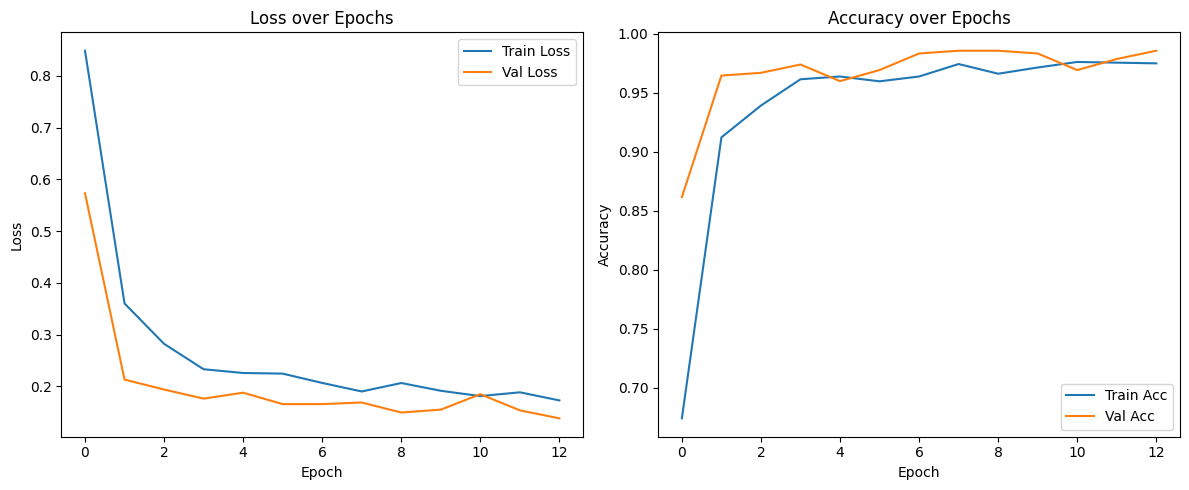

In [ ]:
plt.figure(figsize=(12, 5))

# Потери (Loss)
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Точность (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Построение матрицы ошибок (Confusion Matrix)

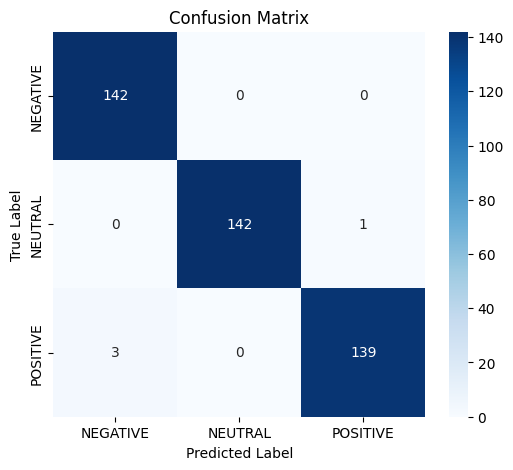

In [ ]:
y_pred_proba = final_model.predict(X_test_sel)
y_pred = y_pred_proba.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Выводы

В рамках проекта была решена задача автоматической классификации эмоционального состояния человека на основе данных ЭЭГ.

Для подготовки данных была проведена:
*   Нормализация признаков
*   Разделение данных на обучающую и тестовую выборки

Чтобы улучшить обобщающую способность моделей и уменьшить размерность пространства, мы протестировали несколько методов отбора признаков:
* SelectKBest (на основе статистики ANOVA F-test)
* SelectFromModel с использованием RandomForestClassifier
* L1-регуляризованный LinearSVC, отбирающий признаки с ненулевыми коэффициентами

По результатам перекрестной проверки (3-fold StratifiedKFold), лучший результат показал метод L1_LinearSVC, который оставил 196 признаков из более чем 1500. Это позволило значительно сократить входное пространство и ускорить обучение, не потеряв в точности.

Следующим шагом было обучение рекуррентной нейросети, способной обрабатывать временные зависимости. Для этого использовалась архитектура с GRU-слоем:
* Выходной слой softmax предсказывает одну из трех эмоций
* Гиперпараметры (кол-во нейронов, dropout, learning rate) подбирались вручную
* Обучение контролировалось с помощью EarlyStopping

Результаты:
* Accuracy: 0.9461
* F1-мера: 0.9415

Наилучшая точность у нейтрального класса — почти 0.99, модель очень хорошо распознаёт состояния «спокойствия» или «отсутствия выраженной эмоции».

Однако в классе POSITIVE заметна проблема с recall — модель не всегда «узнаёт» позитивные эмоции, и часть таких случаев ошибочно относит к другим категориям.

Модель показала очень достойный результат и вполне пригодна для реальных задач. Она лёгкая, обучается быстро и не требует сложных архитектур. Однако её слабое место — возможное «смешение» позитивных и нейтральных сигналов.

Для улучшения качества классификации была построена гибридная модель CNN + GRU, объединяющая:
* Сверточные слои (Conv1D) — выявляют локальные паттерны в сигналах.
* GRU — фиксируют временные зависимости в преобразованных данных.
* Полносвязные слои и softmax — формируют итоговый прогноз.

Результаты:
* Accuracy: 0.9857
* F1-мера: 0.9844

Все классы предсказываются почти идеально: recall и precision по каждому классу около 0.98–0.99.

Модель уверенно различает даже похожие по структуре эмоции, не теряя точности.

Эта модель продемонстрировала хорошее качество и явно превосходит GRU по всем показателям. Она не только точнее, но и устойчивее — даже сложные сигналы классифицируются корректно.

В реальных условиях, например, при создании систем для эмоциональной адаптации приложений или анализа психоэмоционального состояния, гибридная архитектура CNN+GRU будет наиболее оправданным выбором. Однако для быстрого прототипирования и менее критичных задач можно использовать и GRU, которая даёт очень конкурентоспособные результаты.